# <center> Homework 93 </center>

## Task 1 & 2

In [100]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
from importlib import reload
import clustering_alg
from sklearn.metrics import silhouette_score

In [24]:
blob_centers = np.array([[ 0.2,  2.3], [-1.5 ,  2.3], [-2.8,  1.8], [-2.8,  2.8], [-2.8,  1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=blob_std, random_state=7)

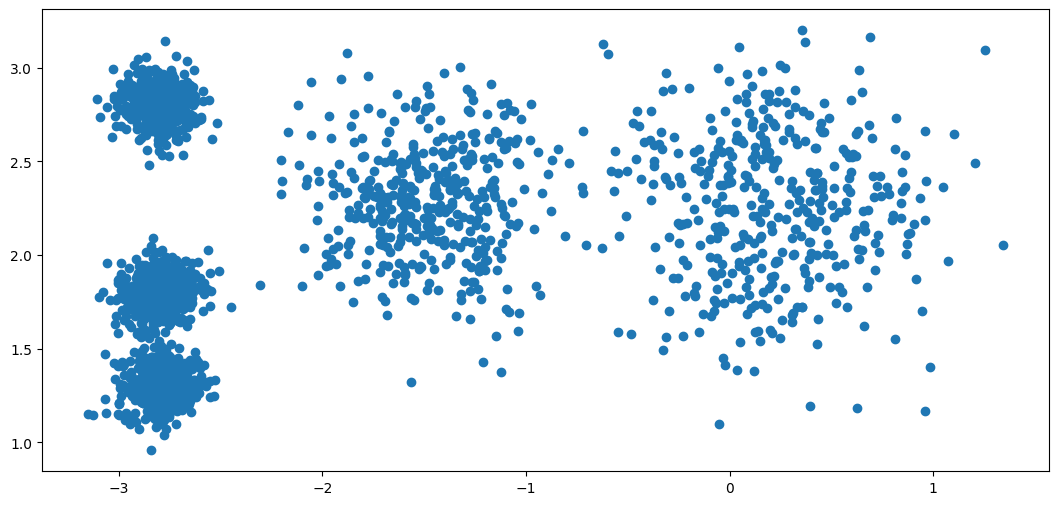

In [25]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.scatter(X[:, 0], X[:, 1])

--------------------- Original ---------------------
13


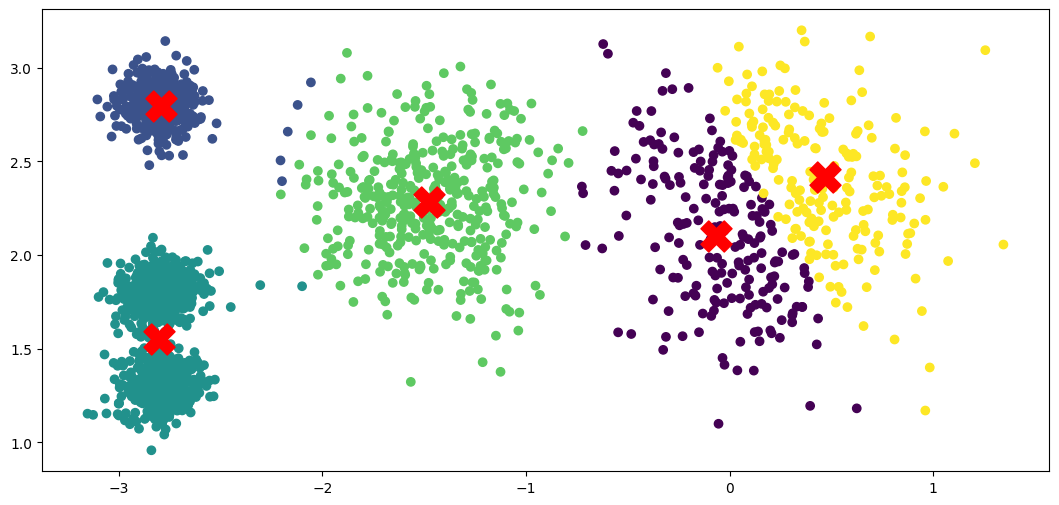

In [174]:
from sklearn.cluster import KMeans
org_kmeans = KMeans(n_clusters=5, init='k-means++', n_init=1, random_state=42).fit(X)

print('--------------------- Original ---------------------')
print(org_kmeans.n_iter_)
fig, ax = plt.subplots(figsize=(13, 6))
org_centers = org_kmeans.cluster_centers_
org_labels = org_kmeans.labels_
ax.scatter(X[:, 0], X[:, 1], c=org_labels)
ax.scatter(org_centers[:, 0], org_centers[:, 1], s=500, marker='X', c='r')

--------------------- Custom ---------------------
9


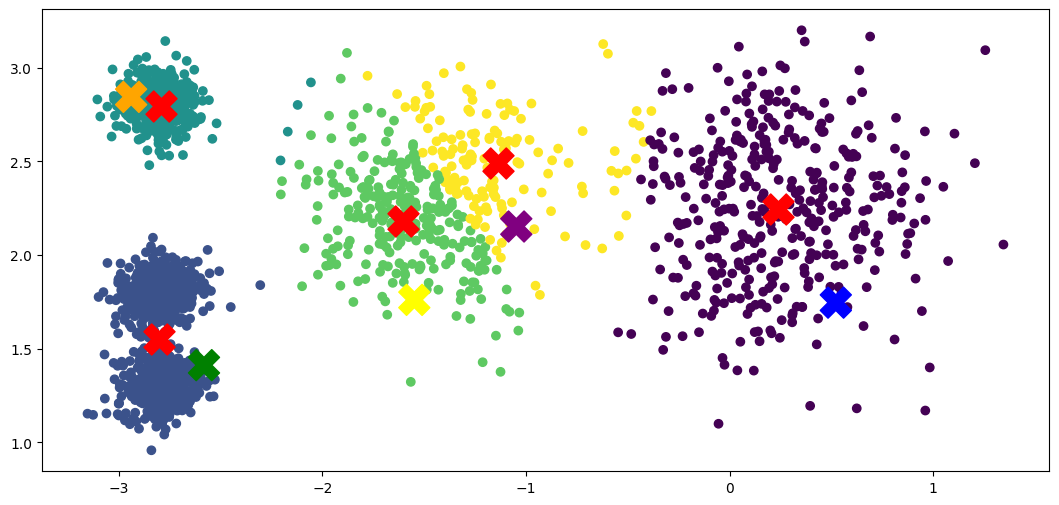

In [175]:
reload(clustering_alg)
from clustering_alg import KMeans
custom_kmeans = KMeans(n_clusters=5, init='k-means++', n_init=1, random_state=42).fit(X)

print('--------------------- Custom ---------------------')
print(custom_kmeans.n_iter_)
fig, ax = plt.subplots(figsize=(13, 6))
custom_centers = custom_kmeans.cluster_centers_
custom_start_init = custom_kmeans.start_
custom_labels = custom_kmeans.labels_

ax.scatter(X[:, 0], X[:, 1], c=custom_labels)
ax.scatter(custom_centers[:, 0], custom_centers[:, 1], s=500, marker='X', c='r')
ax.scatter(custom_start_init[:, 0], custom_start_init[:, 1], s=500, marker='X', c=['blue', 'green', 'orange', 'yellow', 'purple'])

--------------------- Original ---------------------
3
211.5985372581684


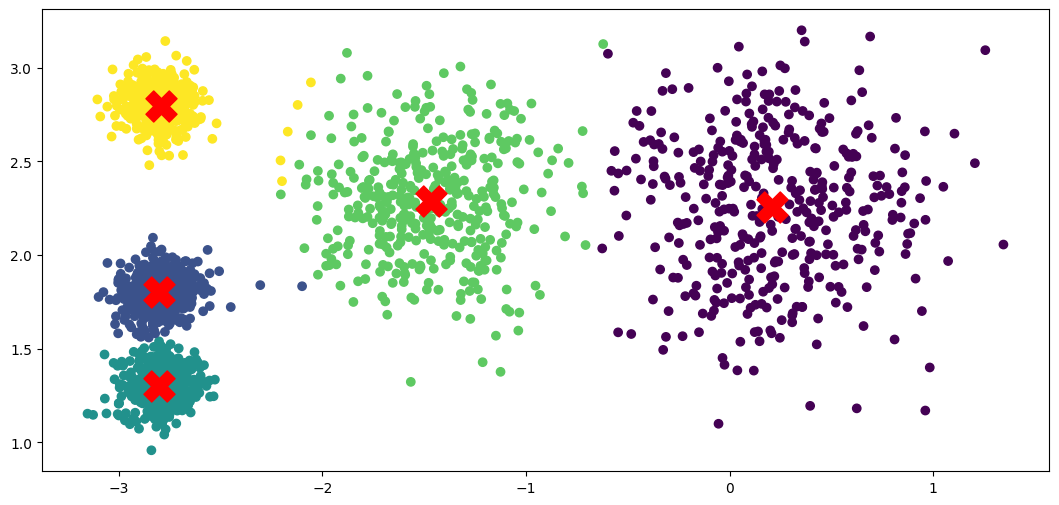

In [176]:
from sklearn.cluster import KMeans
org_kmeans = KMeans(n_clusters=5, init='random', n_init=10, random_state=42).fit(X)

print('--------------------- Original ---------------------')
print(org_kmeans.n_iter_)
print(org_kmeans.inertia_)

fig, ax = plt.subplots(figsize=(13, 6))
org_centers = org_kmeans.cluster_centers_
org_labels = org_kmeans.labels_
ax.scatter(X[:, 0], X[:, 1], c=org_labels)
ax.scatter(org_centers[:, 0], org_centers[:, 1], s=500, marker='X', c='r')

--------------------- Custom ---------------------
6
211.59853725816836


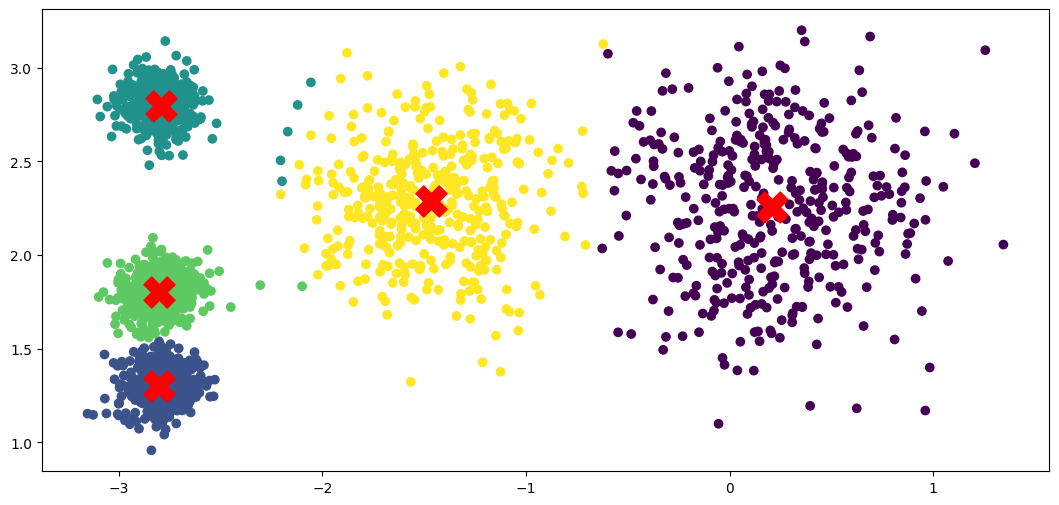

In [177]:
reload(clustering_alg)
from clustering_alg import KMeans
custom_kmeans = KMeans(n_clusters=5, init='random', n_init=10, random_state=42).fit(X)

print('--------------------- Custom ---------------------')
print(custom_kmeans.n_iter_)
print(custom_kmeans.inertia_)

fig, ax = plt.subplots(figsize=(13, 6))
custom_centers = custom_kmeans.cluster_centers_
custom_start_init = custom_kmeans.start_
custom_labels = custom_kmeans.labels_

ax.scatter(X[:, 0], X[:, 1], c=custom_labels)
ax.scatter(custom_centers[:, 0], custom_centers[:, 1], s=500, marker='X', c='r')
# ax.scatter(custom_start_init[:, 0], custom_start_init[:, 1], s=500, marker='X', c=['blue', 'green', 'orange', 'yellow', 'purple'])

--------------------- Custom ---------------------
5


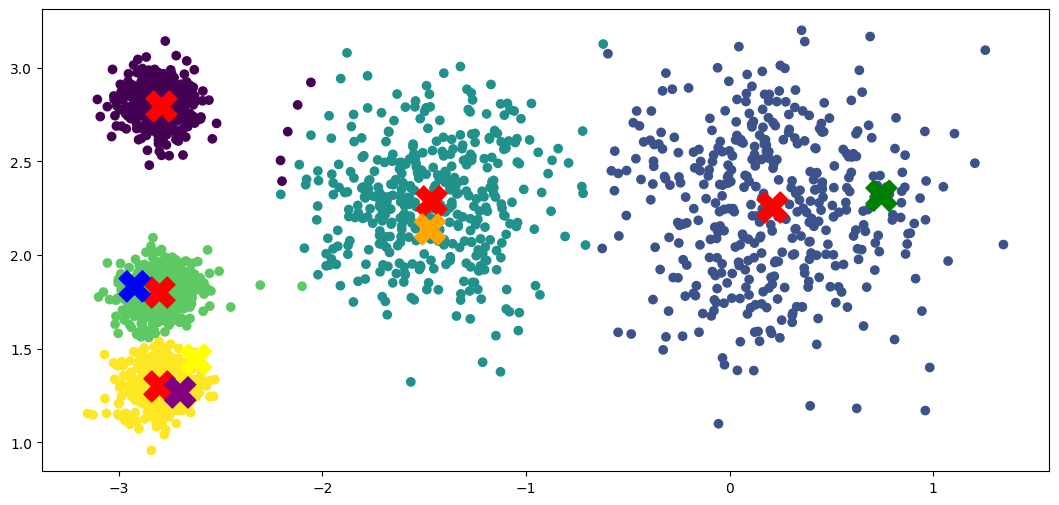

In [178]:
reload(clustering_alg)
from clustering_alg import KMeans
custom_kmeans = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42).fit(X)

print('--------------------- Custom ---------------------')
print(custom_kmeans.n_iter_)
fig, ax = plt.subplots(figsize=(13, 6))
custom_centers = custom_kmeans.cluster_centers_
custom_start_init = custom_kmeans.start_
custom_labels = custom_kmeans.labels_

ax.scatter(X[:, 0], X[:, 1], c=custom_labels)
ax.scatter(custom_centers[:, 0], custom_centers[:, 1], s=500, marker='X', c='r')
ax.scatter(custom_start_init[:, 0], custom_start_init[:, 1], s=500, marker='X', c=['blue', 'green', 'orange', 'yellow', 'purple'])

## Task 3

In [59]:
blob_centers = np.array([[ 0.2,  2.3], [-2 ,  2.3], [-3.8,  2.4], [-3.8,  3.5], [-3.8,  1.3]])
blob_std = np.array([0.5, 0.4, 0.2, 0.2, 0.2])
X, y = make_blobs(n_samples=10_000, centers=blob_centers, cluster_std=blob_std, random_state=7)

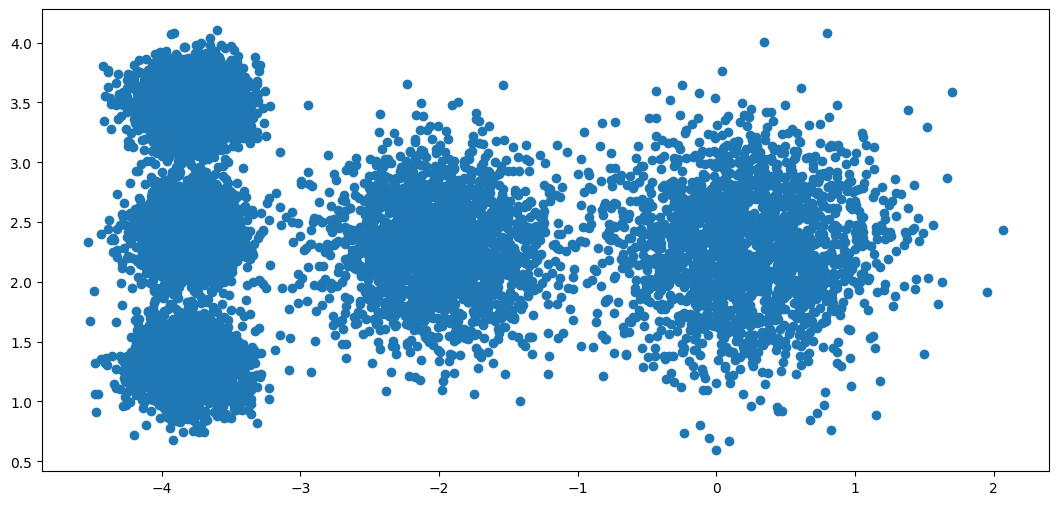

In [60]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.scatter(X[:, 0], X[:, 1])

Custom: 2036.9870096561408 Fit Time: 0.35568809509277344 Iters: 6
Original: 2028.0450336561262 Fit Time: 0.0533754825592041 Iters: 3


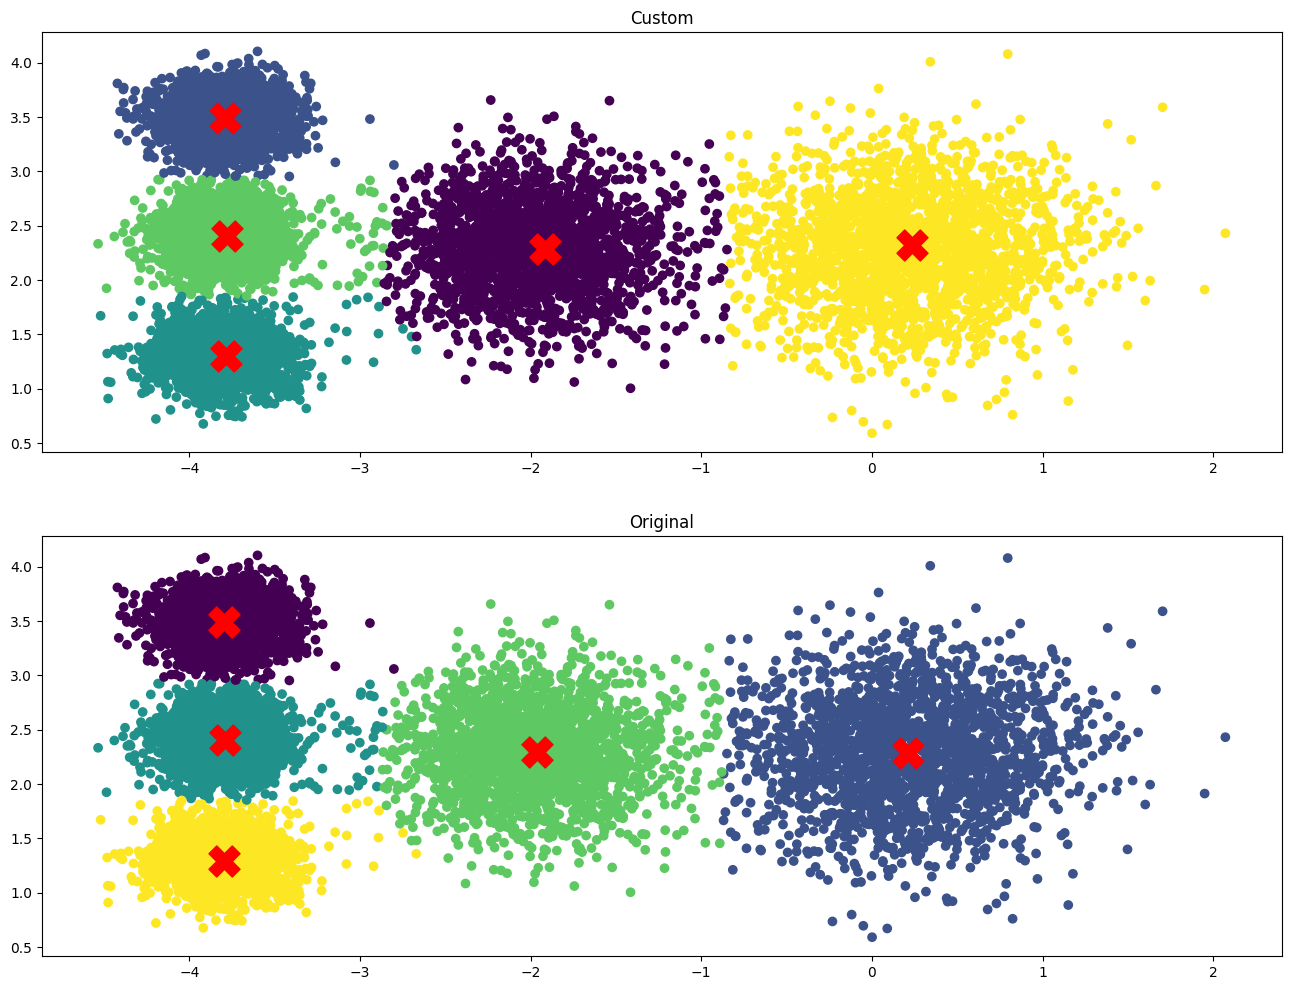

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(16, 12))

# ---------- Custom ----------
reload(clustering_alg)
from clustering_alg import MiniBatchKMeans
mini_kmeans_c = MiniBatchKMeans(5, n_init=5, random_state=42)
start_c = time.time()
mini_kmeans_c.fit(X)
stop_c = time.time()

labels_c = mini_kmeans_c.labels_
centers_c = mini_kmeans_c.cluster_centers_
print('Custom:', mini_kmeans_c.inertia_, 'Fit Time:', stop_c - start_c, 'Iters:', mini_kmeans_c.n_iter_)

ax[0].scatter(X[:, 0], X[:, 1], c=labels_c)
ax[0].scatter(centers_c[:, 0], centers_c[:, 1], c='r', marker='X', s=500)
ax[0].set_title('Custom')
# ---------- Original ----------
from sklearn.cluster import MiniBatchKMeans
mini_kmeans_o = MiniBatchKMeans(5, n_init=5, random_state=42)
start_o = time.time()
mini_kmeans_o.fit(X)
stop_o = time.time()

labels_o = mini_kmeans_o.labels_
centers_o = mini_kmeans_o.cluster_centers_
print('Original:', mini_kmeans_o.inertia_, 'Fit Time:', stop_o - start_o, 'Iters:', mini_kmeans_o.n_iter_)

ax[1].scatter(X[:, 0], X[:, 1], c=labels_o)
ax[1].scatter(centers_o[:, 0], centers_o[:, 1], c='r', marker='X', s=500)
ax[1].set_title('Original')

plt.show()

In [91]:
reload(clustering_alg)
from clustering_alg import KMeans, MiniBatchKMeans

kmeans_inertials = []
minibatch_inertials = []

kmeans_fittime = []
minibatch_fittime = []

k_list = np.arange(2, 101)

for k in range(2, 101):
    kmeans = KMeans(k)
    start = time.time()    
    kmeans.fit(X)
    end = time.time()
    kmeans_fittime.append(end - start)
    kmeans_inertials.append(kmeans.inertia_)

    minibatch = MiniBatchKMeans(k)
    start = time.time()
    minibatch.fit(X)
    end = time.time()
    minibatch_fittime.append(end - start)
    minibatch_inertials.append(minibatch.inertia_)

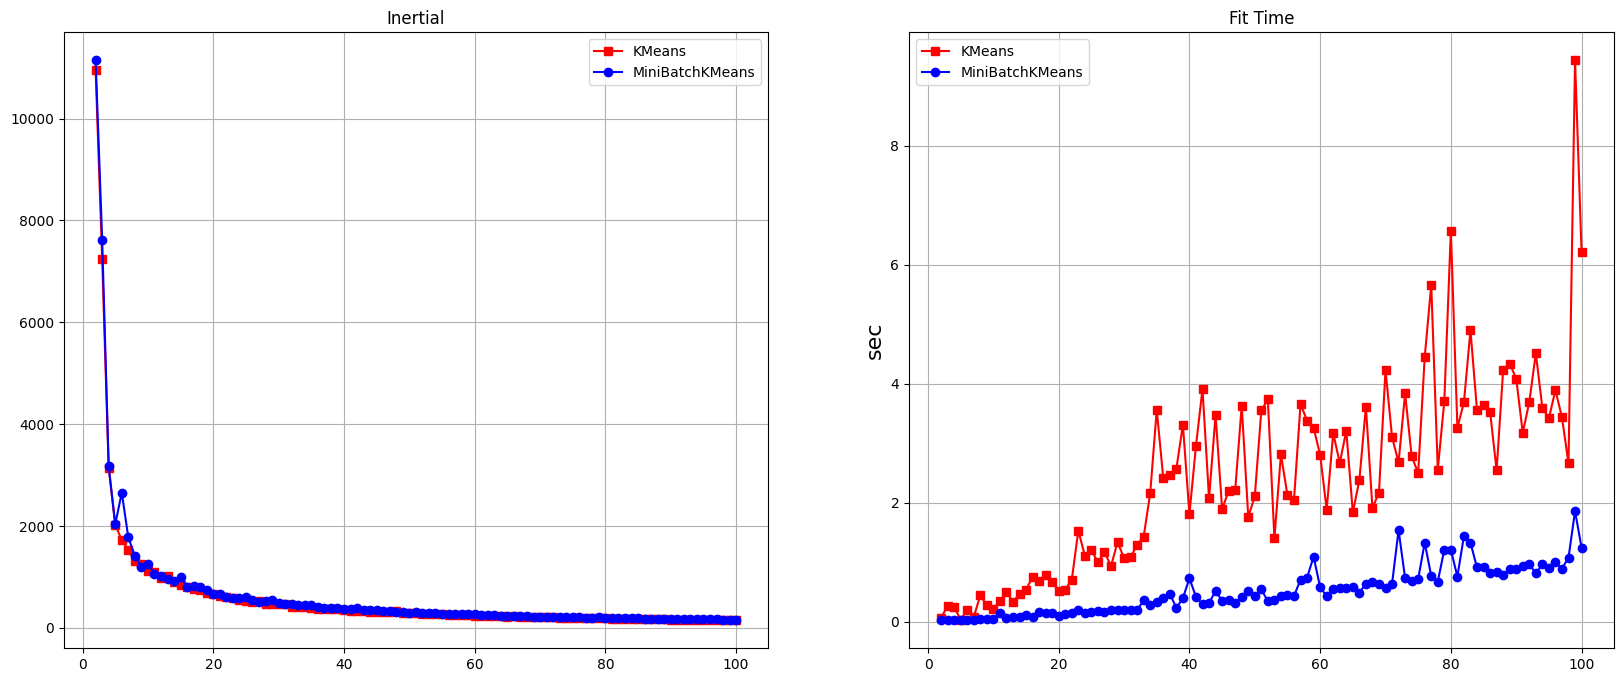

In [99]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

ax[0].set_title('Inertial')
ax[0].plot(k_list, kmeans_inertials, marker='s', c='r', label='KMeans')
ax[0].plot(k_list, minibatch_inertials, marker='o', c='b', label='MiniBatchKMeans')
ax[0].legend()
ax[0].grid()

ax[1].set_title('Fit Time')
ax[1].plot(k_list, kmeans_fittime, marker='s', c='r', label='KMeans')
ax[1].plot(k_list, minibatch_fittime, marker='o', c='b', label='MiniBatchKMeans')
ax[1].set_ylabel('sec', fontsize=16)
ax[1].legend()
ax[1].grid()

plt.show()

In [ ]:
reload(clustering_alg)
from clustering_alg import KMeans, MiniBatchKMeans, silhouette_score

n_samples = X.shape[0]
batch_size = n_samples // 10

np.random.seed(42)
inxs = np.random.permutation(n_samples)

batches_inxs = np.array_split(inxs, batch_size)

kmeans = KMeans(5, n_init=1)
minibatch = MiniBatchKMeans(5)
centers = None

for batch_i in batches_inxs:
    X_batch = X[batch_i]

    if centers is not None:
        kmeans = KMeans(5, n_init=1, init=centers)
    
    kmeans.fit(X_batch)
    centers = kmeans.cluster_centers_

    minibatch.partial_fit(X_batch)

In [110]:
def get_inertia(X, labels, centers):
    center_per_point = centers[labels]
    return ((X - center_per_point) ** 2).sum(axis=1).sum()

kmeans_labels = kmeans.predict(X)
minibatch_labels = minibatch.predict(X)

kmeans_centers = kmeans.cluster_centers_
minibatch_centers = minibatch.cluster_centers_

kmeans_silhouette = silhouette_score(X, kmeans_labels)
minibatch_silhouette = silhouette_score(X, minibatch_labels)

kmeans_inertia = get_inertia(X, kmeans_labels, kmeans_centers)
minibatch_inertia = get_inertia(X, minibatch_labels, minibatch_centers)

In [112]:
rows = ['Inertia', 'Silhouette Score']
cols = ['KMenas', 'MiniBatchKMeans']
data = [
    [kmeans_inertia, minibatch_inertia],
    [kmeans_silhouette, minibatch_silhouette]
]

pd.DataFrame(data, rows, cols)

,KMenas,MiniBatchKMeans
Inertia,4610.684982,2027.878346
Silhouette Score,0.491769,0.632678


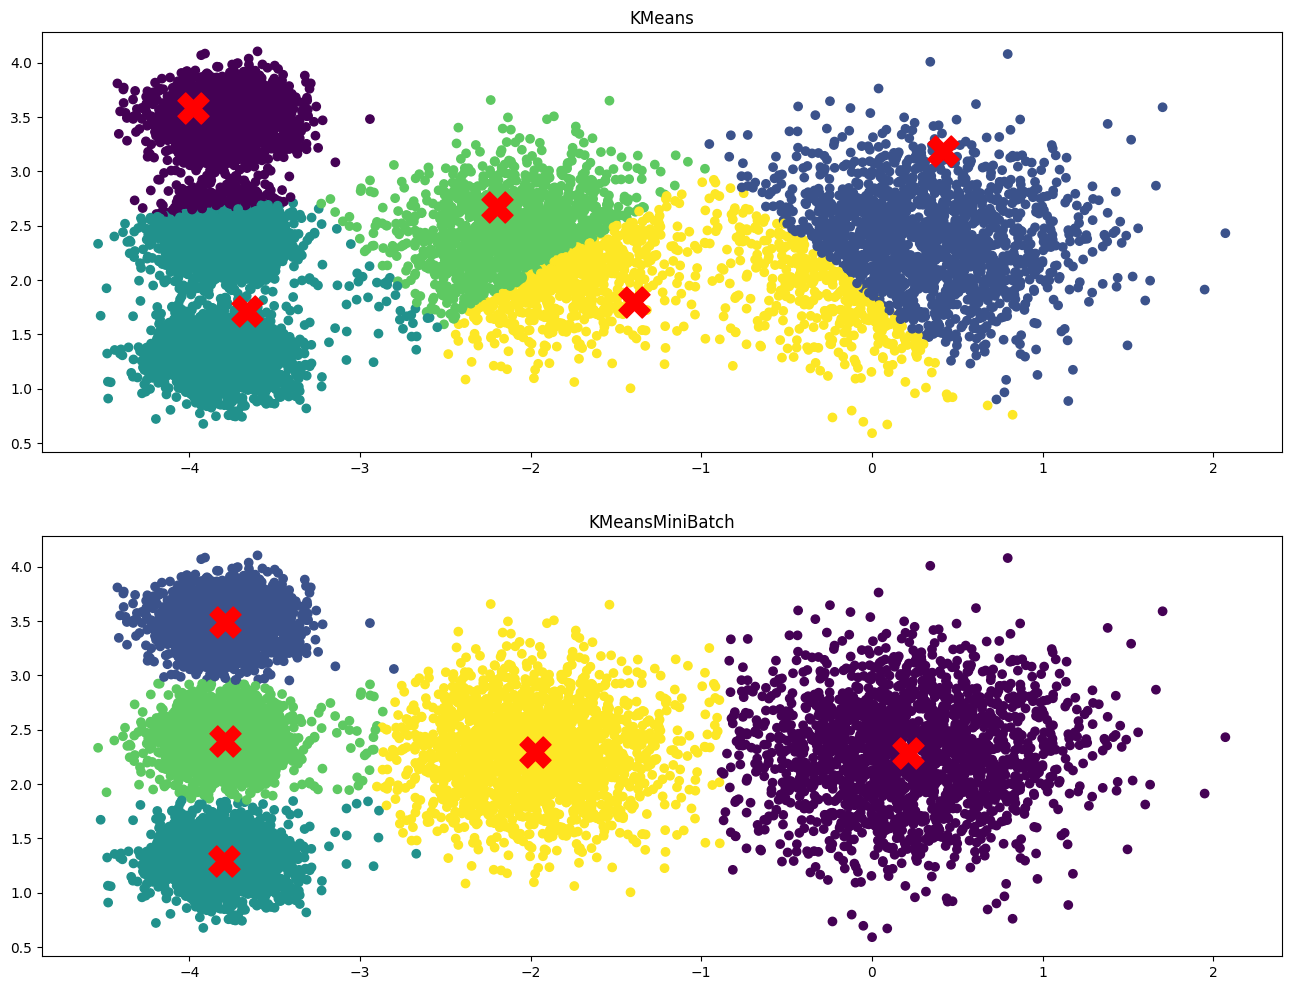

In [116]:
fig, ax = plt.subplots(2, 1, figsize=(16, 12))

# -------- KMeans --------
ax[0].set_title('KMeans')
ax[0].scatter(X[:, 0], X[:, 1], c=kmeans_labels)
ax[0].scatter(kmeans_centers[:, 0], kmeans_centers[:, 1], s=500, c='r', marker='X')


# -------- KMeansMiniBatch --------
ax[1].set_title('KMeansMiniBatch')
ax[1].scatter(X[:, 0], X[:, 1], c=minibatch_labels)
ax[1].scatter(minibatch_centers[:, 0], minibatch_centers[:, 1], s=500, c='r', marker='X')

plt.show()

## Task 4

In [41]:
from sklearn.cluster import KMeans

kmenas = KMeans(5, init='random')
kmenas.fit(X)
labels = kmenas.labels_

print('------- Custom -------')
reload(clustering_alg)
from clustering_alg import silhouette_score
print(silhouette_score(X, labels))

print('------- Original -------')
from sklearn.metrics import silhouette_score
print(silhouette_score(X, labels))

------- Custom -------
0.6563802184546098
------- Original -------
0.655517642572828


## Task 5

### random

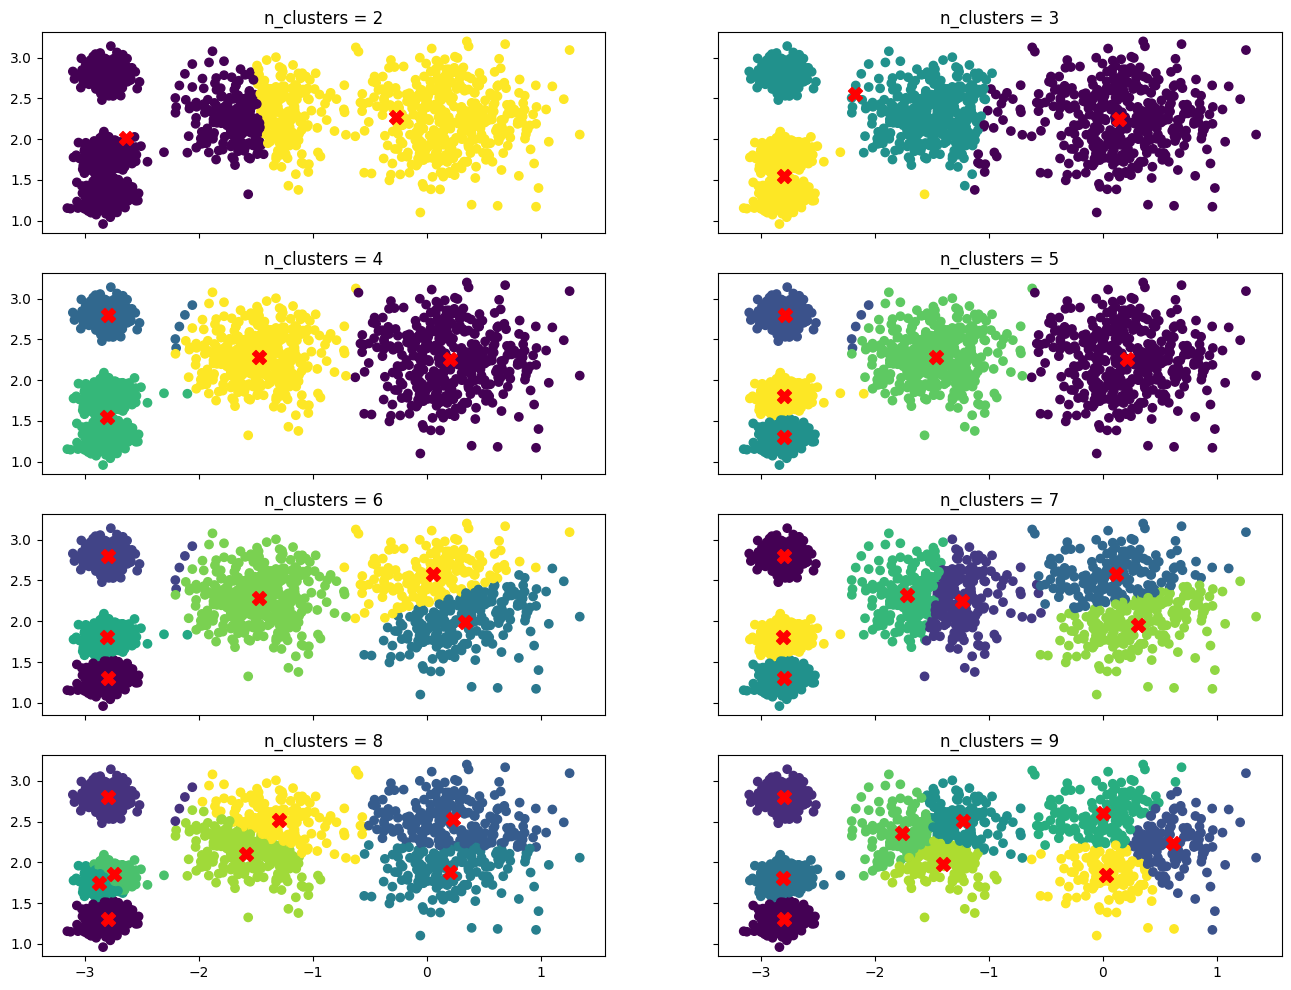

In [31]:
from sklearn.cluster import KMeans

fig, ax = plt.subplots(4, 2, figsize=(16, 12), sharex=True, sharey=True)

inertials = []
silhouette_score_list = []
clusters_list = []
clusters = 2
for i in range(4):
    for j in range(2):
        kmeans = KMeans(clusters, init='random', random_state=45).fit(X)
        inertials.append(kmeans.inertia_)
        labels = kmeans.labels_
        centers = kmeans.cluster_centers_
        ax[i, j].scatter(X[:, 0], X[:, 1], c=labels)
        ax[i, j].scatter(centers[:, 0], centers[:, 1], s=100, marker='X', c='r')
        ax[i, j].set_title(f'n_clusters = {clusters}')
        silhouette_score_list.append(silhouette_score(X, labels))
        clusters_list.append(clusters)
        clusters += 1

plt.show()

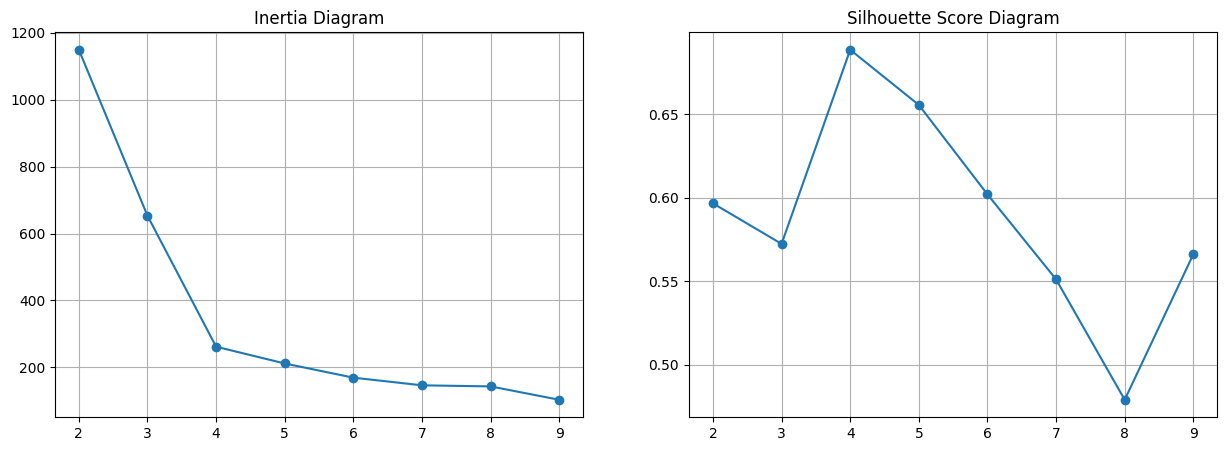

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(clusters_list, inertials, marker='o')
ax[0].set_title('Inertia Diagram')
ax[0].grid()

ax[1].plot(clusters_list, silhouette_score_list, marker='o')
ax[1].set_title('Silhouette Score Diagram')
ax[1].grid()

### k-means++

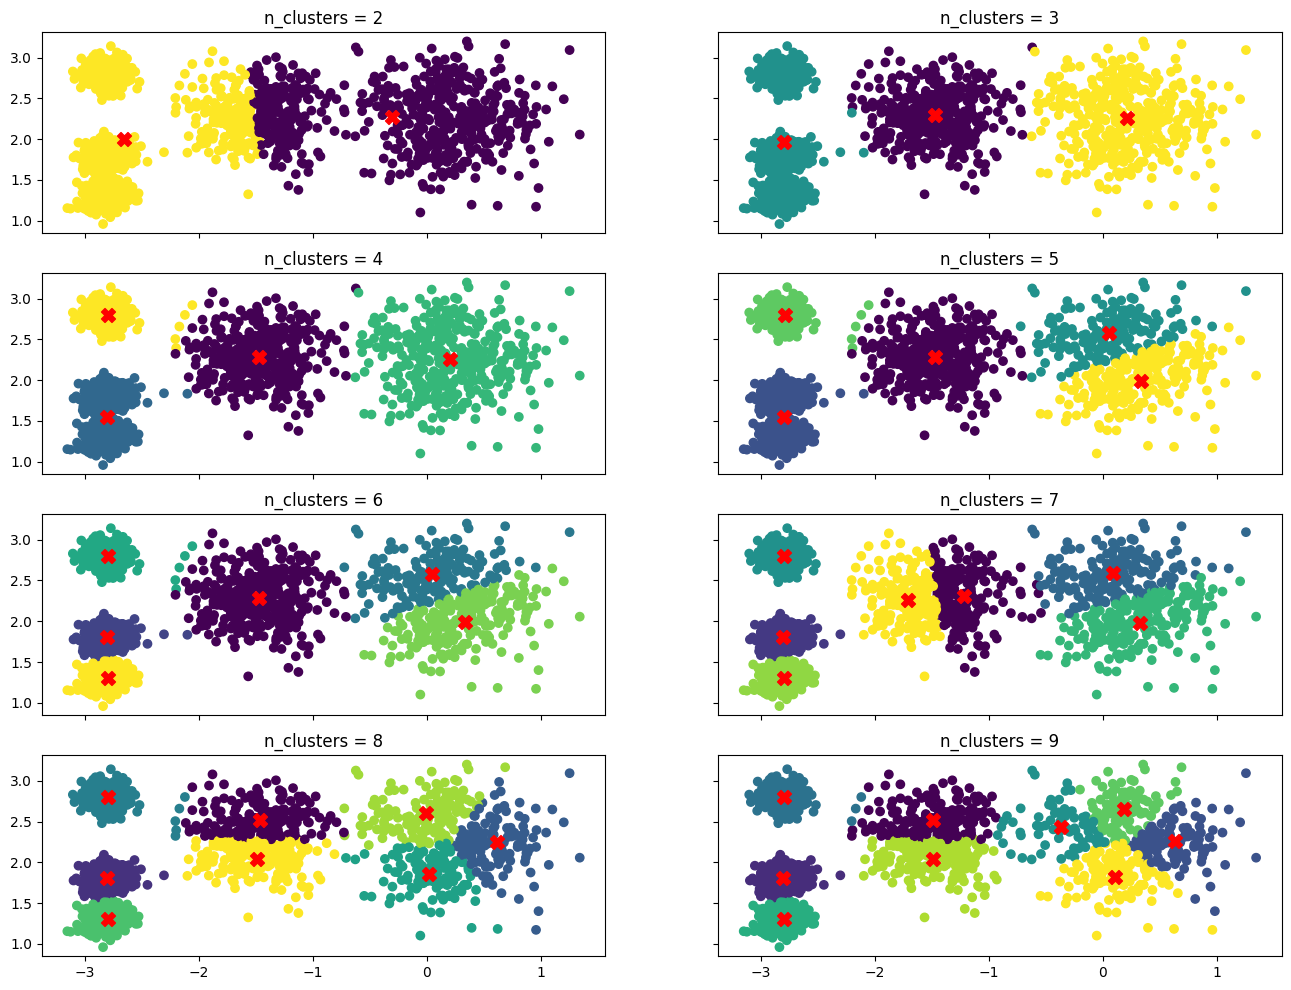

In [33]:
from sklearn.cluster import KMeans

fig, ax = plt.subplots(4, 2, figsize=(16, 12), sharex=True, sharey=True)

inertials = []
silhouette_score_list = []
clusters_list = []
clusters = 2
for i in range(4):
    for j in range(2):
        kmeans = KMeans(clusters, init='k-means++', random_state=45).fit(X)
        inertials.append(kmeans.inertia_)
        labels = kmeans.labels_
        centers = kmeans.cluster_centers_
        ax[i, j].scatter(X[:, 0], X[:, 1], c=labels)
        ax[i, j].scatter(centers[:, 0], centers[:, 1], s=100, marker='X', c='r')
        ax[i, j].set_title(f'n_clusters = {clusters}')
        clusters_list.append(clusters)
        silhouette_score_list.append(silhouette_score(X, labels))

        clusters += 1

plt.show()

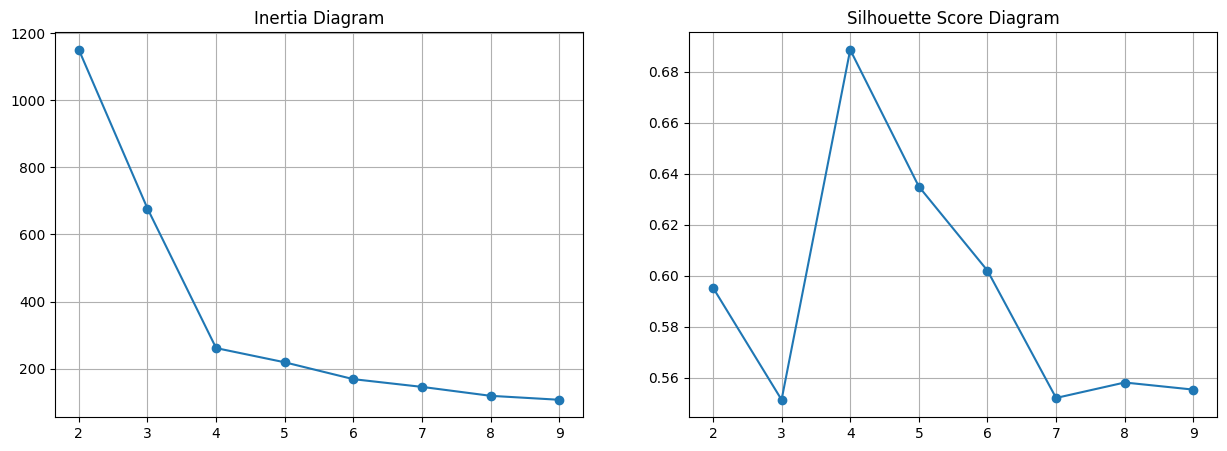

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(clusters_list, inertials, marker='o')
ax[0].set_title('Inertia Diagram')
ax[0].grid()

ax[1].plot(clusters_list, silhouette_score_list, marker='o')
ax[1].set_title('Silhouette Score Diagram')
ax[1].grid()

## Task 6

In [117]:
blob_centers = np.array([[ 0.2,  2.3], [-1.5 ,  2.3], [-2.8,  1.8], [-2.8,  2.8], [-2.8,  1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=blob_std, random_state=7)

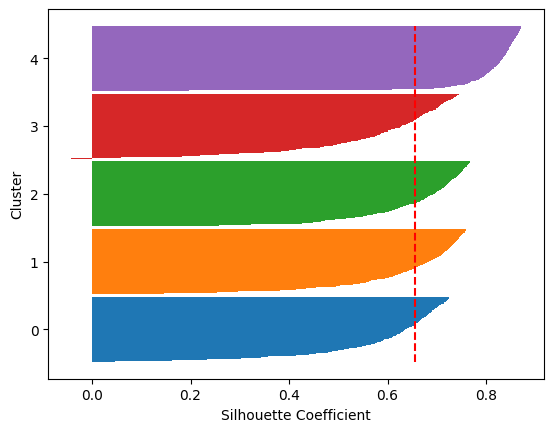

In [173]:
reload(clustering_alg)
from clustering_alg import silhouette_diagram
from sklearn.cluster import KMeans

kmeans = KMeans(5, random_state=42, init='random').fit(X)
labels = kmeans.labels_
silhouette_diagram(X, labels)
plt.show()

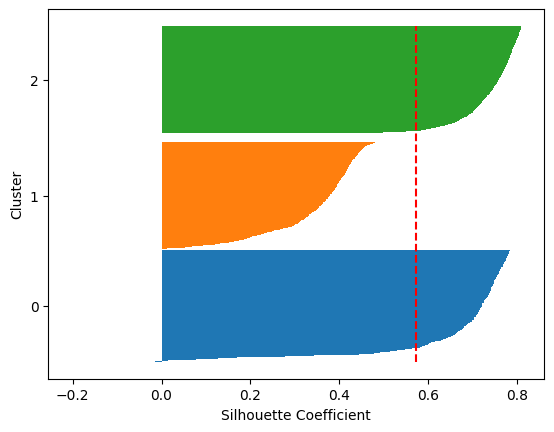

In [167]:
reload(clustering_alg)
from clustering_alg import silhouette_diagram
from sklearn.cluster import KMeans

kmeans = KMeans(3, random_state=42, init='random').fit(X)
labels = kmeans.labels_
silhouette_diagram(X, labels)
plt.show()

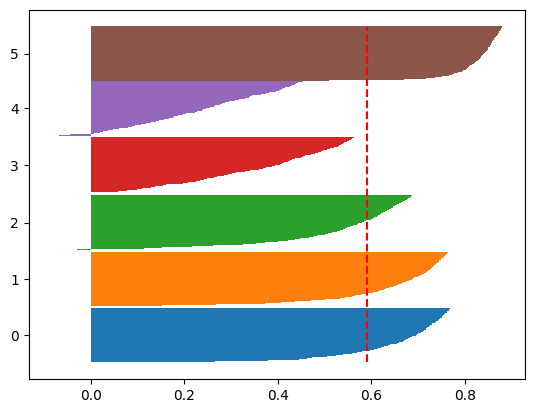

In [165]:
reload(clustering_alg)
from clustering_alg import silhouette_diagram
from sklearn.cluster import KMeans

kmeans = KMeans(6, random_state=42, init='random').fit(X)
labels = kmeans.labels_
silhouette_diagram(X, labels)
plt.show()